# Bài tập Machine Learning — Dự đoán bệnh tiểu đường

## Mục tiêu

1. Xây dựng **3 biểu đồ phân phối** từ `diabetes.csv`.
2. Xây dựng **5 mô hình học máy** cho bài toán phân loại.
3. Đánh giá bằng **5 độ đo**: Accuracy, Precision, Recall, F1-score, ROC-AUC.
4. Thực hiện đủ **3 Controlled Experiments**:
   - Experiment 1 — Model Comparison;
   - Experiment 2 — Hyperparameter Investigation;
   - Experiment 3 — Representation Investigation.
5. Với mô hình **K-Nearest Neighbors (KNN), cố định `k = 19`**.
6. Chọn **Final Model sau cả 3 experiments**, sau đó mới đánh giá trên test set và lưu `.sav`.
7. Chuẩn bị mô hình để triển khai thành ứng dụng trên điện thoại.

### Phát biểu bài toán

Với các đặc trưng sức khỏe của một bệnh nhân:

- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`

dự đoán biến `Outcome`:

- `0`: không mắc tiểu đường;
- `1`: mắc tiểu đường.

Đây là **bài toán phân loại nhị phân (Binary Classification)**.

### Luồng hệ thống

`Thông tin sức khỏe → Representation → Preprocessing → Model → Prediction → Mobile App`


In [1]:
from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


In [2]:
from IPython.display import display

DATA_PATH = r"C:\DATA\diabetes.csv"

df = pd.read_csv(DATA_PATH)

print("Kích thước dataset:", df.shape)
display(df.head())


Kích thước dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Khảo sát dữ liệu ban đầu

Dataset Diabetes thường gồm **8 đặc trưng đầu vào** và 1 biến mục tiêu `Outcome`.

Trong bộ dữ liệu Pima Indians Diabetes, một số cột có thể chứa giá trị `0` nhưng về mặt dữ liệu sức khỏe, `0` ở các cột sau thường được xem như giá trị thiếu:

- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

Ta **không xóa toàn bộ các dòng này**. Thay vào đó:

1. đổi các giá trị `0` ở 5 cột trên thành `NaN`;
2. dùng `SimpleImputer(strategy="median")` để điền giá trị thiếu;
3. dùng `StandardScaler` để chuẩn hóa đặc trưng.

Các cột `Pregnancies`, `DiabetesPedigreeFunction`, `Age` không áp dụng quy tắc đổi `0 → NaN`.

`Outcome` là **target** và phải giữ nguyên 0/1.


In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique()
})
display(info)
display(df.describe(include="all").T)

print("\nPhân bố Outcome:")
display(df["Outcome"].value_counts().sort_index().to_frame("count"))
display(
    (df["Outcome"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .to_frame("percent")
)


,dtype,missing,missing_%,nunique
Pregnancies,int64,0,0.0,17
Glucose,int64,0,0.0,136
BloodPressure,int64,0,0.0,47
SkinThickness,int64,0,0.0,51
Insulin,int64,0,0.0,186
BMI,float64,0,0.0,248
DiabetesPedigreeFunction,float64,0,0.0,517
Age,int64,0,0.0,52
Outcome,int64,0,0.0,2


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Phân bố Outcome:


,count
Outcome,
0,500
1,268


,percent
Outcome,
0,65.1
1,34.9


## 2. Biểu diễn và làm sạch dữ liệu

Mỗi observation có thể biểu diễn dưới dạng vector:

\[
x =
[
Pregnancies,
Glucose,
BloodPressure,
SkinThickness,
Insulin,
BMI,
DiabetesPedigreeFunction,
Age
]
\]

Mô hình học một hàm:

\[
\hat{y} = f_\theta(x)
\]

trong đó:

- `x`: vector đặc trưng của một bệnh nhân;
- `fθ`: mô hình học máy;
- `ŷ`: nhãn dự đoán 0 hoặc 1.

Ta tạo một bản sao dữ liệu và thay các giá trị `0` không hợp lý bằng `NaN`. Việc điền median sẽ được thực hiện **bên trong pipeline** để tránh rò rỉ dữ liệu từ test sang train.


In [4]:
FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

TARGET = "Outcome"

ZERO_AS_MISSING = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

required_columns = FEATURES + [TARGET]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"Dataset đang thiếu các cột cần thiết: {missing_columns}"
    )

df_model = df[required_columns].copy()

for col in ZERO_AS_MISSING:
    df_model[col] = df_model[col].replace(0, np.nan)

print("Số giá trị thiếu sau khi đổi 0 → NaN:")
display(df_model.isna().sum().to_frame("missing"))

display(df_model.head())


Số giá trị thiếu sau khi đổi 0 → NaN:


,missing
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


# 3. Ba biểu đồ phân phối

Ba biểu đồ được chọn để nhìn nhanh cấu trúc dữ liệu:

1. Phân phối `Outcome` — số lượng người thuộc lớp 0 và lớp 1.
2. Phân phối `Glucose` — đặc trưng quan trọng liên quan trực tiếp tới đường huyết.
3. Phân phối `BMI` — cho biết phân bố chỉ số khối cơ thể.


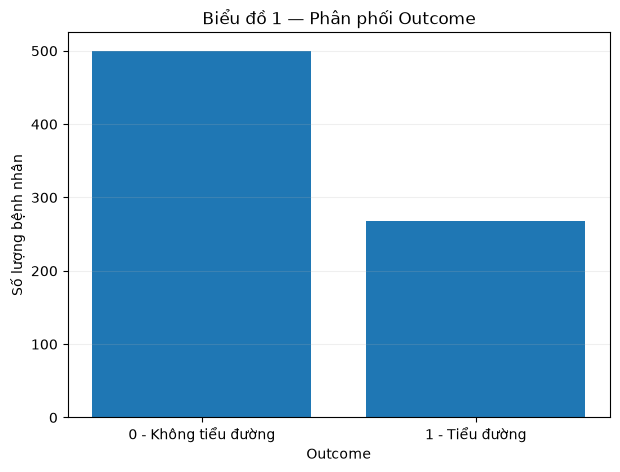

,count
Outcome,
0,500
1,268


In [5]:
# Biểu đồ 1: Phân phối Outcome
outcome_counts = df_model["Outcome"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["0 - Không tiểu đường", "1 - Tiểu đường"],
    outcome_counts.reindex([0, 1], fill_value=0).values
)
plt.title("Biểu đồ 1 — Phân phối Outcome")
plt.xlabel("Outcome")
plt.ylabel("Số lượng bệnh nhân")
plt.grid(axis="y", alpha=0.2)
plt.show()

display(outcome_counts.to_frame("count"))


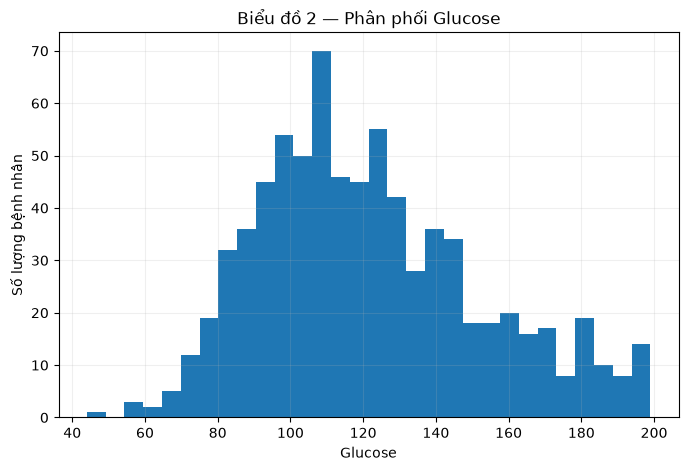

count    763.000000
mean     121.686763
std       30.535641
min       44.000000
25%       99.000000
50%      117.000000
75%      141.000000
max      199.000000
Name: Glucose, dtype: float64


In [6]:
# Biểu đồ 2: Phân phối Glucose
plt.figure(figsize=(8, 5))
plt.hist(df_model["Glucose"].dropna(), bins=30)
plt.title("Biểu đồ 2 — Phân phối Glucose")
plt.xlabel("Glucose")
plt.ylabel("Số lượng bệnh nhân")
plt.grid(alpha=0.2)
plt.show()

print(df_model["Glucose"].describe())


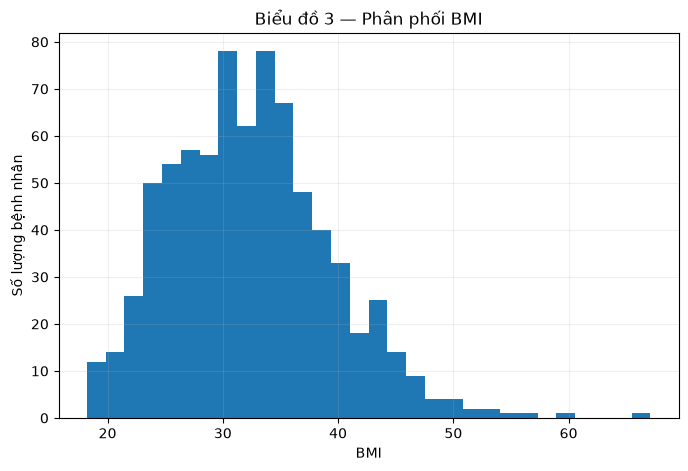

count    757.000000
mean      32.457464
std        6.924988
min       18.200000
25%       27.500000
50%       32.300000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64


In [7]:
# Biểu đồ 3: Phân phối BMI
plt.figure(figsize=(8, 5))
plt.hist(df_model["BMI"].dropna(), bins=30)
plt.title("Biểu đồ 3 — Phân phối BMI")
plt.xlabel("BMI")
plt.ylabel("Số lượng bệnh nhân")
plt.grid(alpha=0.2)
plt.show()

print(df_model["BMI"].describe())


# 4. Chuẩn bị dữ liệu huấn luyện

## Feature sử dụng

Tám feature số:

- `Pregnancies`
- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`
- `DiabetesPedigreeFunction`
- `Age`

## Tiền xử lý

Pipeline chuẩn:

```text
Missing value
→ Median Imputation
→ StandardScaler
→ Classifier
```

Để tránh dùng test set trong quá trình lựa chọn/tuning model, dữ liệu được chia theo 2 bước:

```text
Toàn bộ dataset
├── Train + Validation: 80%
│   ├── Experiment Train: 75% của phần này
│   └── Validation:      25% của phần này
└── Test: 20%
```

Tương đương gần:

```text
60% experiment train
20% validation
20% final test
```

- **Experiment Train**: fit model trong các experiments.
- **Validation**: so sánh model/hyperparameter/representation.
- **Test**: chỉ dùng sau khi đã chọn Final Model.


In [8]:
X = df_model[FEATURES].copy()
y = df_model[TARGET].astype(int).copy()

# Pipeline preprocessing chuẩn
standard_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Representation không scale, dùng cho Experiment 3
unscaled_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# 80% train+validation, 20% test cuối cùng
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Từ 80% trên, lấy 25% làm validation
# => khoảng 60% experiment train, 20% validation, 20% test
X_exp_train, X_val, y_exp_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

print("Experiment train:", X_exp_train.shape)
print("Validation      :", X_val.shape)
print("Final test      :", X_test.shape)

print("\nTỷ lệ Outcome:")
display(pd.DataFrame({
    "Experiment Train": y_exp_train.value_counts(normalize=True).sort_index(),
    "Validation": y_val.value_counts(normalize=True).sort_index(),
    "Final Test": y_test.value_counts(normalize=True).sort_index(),
}).round(4))


Experiment train: (460, 8)
Validation      : (154, 8)
Final test      : (154, 8)

Tỷ lệ Outcome:


,Experiment Train,Validation,Final Test
Outcome,,,
0,0.6522,0.6494,0.6494
1,0.3478,0.3506,0.3506


## Baseline

Baseline không được tính vào 5 mô hình chính.

Dùng:

```python
DummyClassifier(strategy="most_frequent")
```

Baseline được fit trên **Experiment Train** và đánh giá trên **Validation**.


In [9]:
baseline = Pipeline([
    ("preprocess", clone(standard_preprocessor)),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_exp_train, y_exp_train)

baseline_pred = baseline.predict(X_val)
baseline_prob = baseline.predict_proba(X_val)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_val, baseline_pred),
    "Precision": precision_score(y_val, baseline_pred, zero_division=0),
    "Recall": recall_score(y_val, baseline_pred, zero_division=0),
    "F1": f1_score(y_val, baseline_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_val, baseline_prob),
}

display(pd.DataFrame([baseline_metrics], index=["Baseline"]).round(4))


,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline,0.6494,0.0,0.0,0.0,0.5


# 5. Năm mô hình Machine Learning

Năm mô hình chính:

1. Logistic Regression
2. **KNN (`k = 19`)**
3. Decision Tree
4. Random Forest
5. SVM RBF

> `k = 19` được giữ cố định theo yêu cầu bài.


In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "KNN (k=19)": KNeighborsClassifier(
        n_neighbors=19,
        weights="uniform",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "SVM RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE
    ),
}

print("K của KNN:", models["KNN (k=19)"].n_neighbors)


K của KNN: 19


# 6. Experiment 1 — Model Comparison

## Experimental Question

> Khi giữ nguyên dataset, preprocessing, split và evaluation protocol, model nào cho performance tốt nhất?

Controlled experiment:

```text
Same data
Same split
Same representation
Same preprocessing
Same metrics
Different model
```

Tất cả 5 model dùng **StandardScaler** và được so sánh trên **Validation set**.

Tiêu chí xếp hạng chính: **F1-score**.  
Nếu F1 gần nhau, xem thêm **ROC-AUC** và **Recall**.


In [11]:
experiment1_results = []
experiment1_models = {}

for name, estimator in models.items():
    start = time.time()

    pipeline = Pipeline([
        ("preprocess", clone(standard_preprocessor)),
        ("model", clone(estimator))
    ])

    pipeline.fit(X_exp_train, y_exp_train)

    y_pred = pipeline.predict(X_val)
    y_score = pipeline.predict_proba(X_val)[:, 1]

    experiment1_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1": f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_score),
        "Training + prediction time (s)": time.time() - start,
    })

    experiment1_models[name] = pipeline

experiment1_df = (
    pd.DataFrame(experiment1_results)
    .sort_values(
        by=["F1", "ROC-AUC", "Recall"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

display(experiment1_df.round(4))

experiment1_winner = experiment1_df.iloc[0]["Model"]

print("Experiment 1 winner:", experiment1_winner)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training + prediction time (s)
0,Logistic Regression,0.7792,0.7273,0.5926,0.6531,0.8498,0.0311
1,Random Forest,0.7662,0.6957,0.5926,0.6400,0.8583,0.4105
2,SVM RBF,0.7727,0.7317,0.5556,0.6316,0.8530,0.0419
3,KNN (k=19),0.7597,0.6977,0.5556,0.6186,0.8656,0.0690
4,Decision Tree,0.7662,0.7647,0.4815,0.5909,0.8662,0.0274


Experiment 1 winner: Logistic Regression


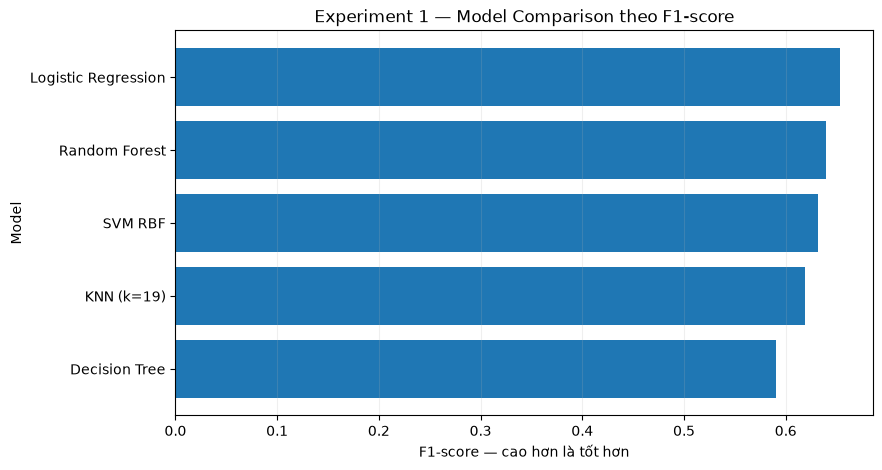

In [12]:
ranking = experiment1_df.sort_values("F1", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(ranking["Model"], ranking["F1"])
plt.title("Experiment 1 — Model Comparison theo F1-score")
plt.xlabel("F1-score — cao hơn là tốt hơn")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.2)
plt.show()


# 7. Experiment 2 — Hyperparameter Investigation

## Experimental Question

> Việc thay đổi `max_depth` của Decision Tree ảnh hưởng như thế nào đến classification performance?

Trong experiment này chỉ thay đổi **một meaningful hyperparameter**:

```text
max_depth
```

Các yếu tố khác được giữ nguyên.

> KNN vẫn giữ `k = 19`; Experiment 2 không thay đổi `k`.


In [13]:
depth_values = [2, 3, 4, 5, 6, 8, 10, None]

experiment2_results = []
experiment2_models = {}

for depth in depth_values:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    )

    pipeline = Pipeline([
        ("preprocess", clone(standard_preprocessor)),
        ("model", tree)
    ])

    pipeline.fit(X_exp_train, y_exp_train)

    y_pred = pipeline.predict(X_val)
    y_score = pipeline.predict_proba(X_val)[:, 1]

    depth_label = "None" if depth is None else str(depth)

    experiment2_results.append({
        "max_depth": depth_label,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1": f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_score),
    })

    experiment2_models[depth_label] = pipeline

experiment2_df = (
    pd.DataFrame(experiment2_results)
    .sort_values(
        by=["F1", "ROC-AUC", "Recall"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

display(experiment2_df.round(4))

best_depth_label = experiment2_df.iloc[0]["max_depth"]
best_depth = None if best_depth_label == "None" else int(best_depth_label)

print("Best max_depth:", best_depth)


,max_depth,Accuracy,Precision,Recall,F1,ROC-AUC
0,4,0.7857,0.6981,0.6852,0.6916,0.8538
1,6,0.7857,0.7234,0.6296,0.6733,0.8488
2,10,0.7792,0.7381,0.5741,0.6458,0.8267
3,None,0.7792,0.7381,0.5741,0.6458,0.8267
4,8,0.7792,0.7632,0.5370,0.6304,0.8184
5,2,0.7532,0.6667,0.5926,0.6275,0.7985
6,5,0.7662,0.7647,0.4815,0.5909,0.8662
7,3,0.7727,0.8065,0.4630,0.5882,0.8555


Best max_depth: 4


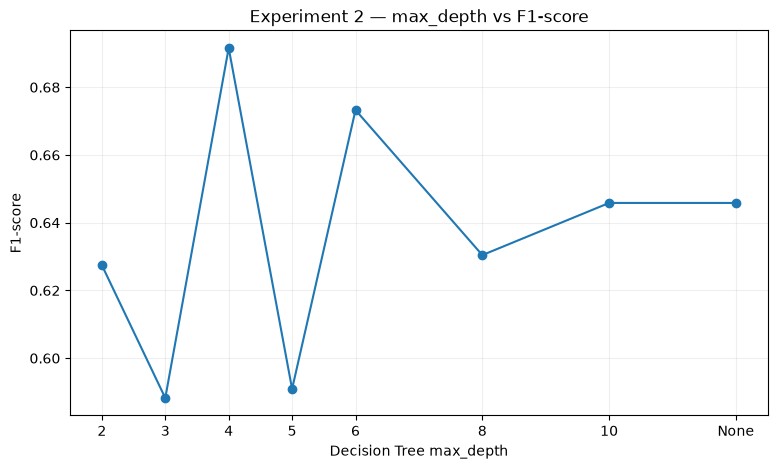

In [14]:
plot_df = experiment2_df.copy()

# Chỉ để biểu đồ dễ đọc: None được đặt sau giá trị depth lớn nhất.
plot_df["depth_for_plot"] = plot_df["max_depth"].replace(
    {"None": str(max(d for d in depth_values if d is not None) + 2)}
).astype(int)

plot_df = plot_df.sort_values("depth_for_plot")

plt.figure(figsize=(9, 5))
plt.plot(
    plot_df["depth_for_plot"],
    plot_df["F1"],
    marker="o"
)

labels = [
    "None" if x == max(d for d in depth_values if d is not None) + 2 else str(x)
    for x in plot_df["depth_for_plot"]
]

plt.xticks(plot_df["depth_for_plot"], labels)
plt.title("Experiment 2 — max_depth vs F1-score")
plt.xlabel("Decision Tree max_depth")
plt.ylabel("F1-score")
plt.grid(alpha=0.2)
plt.show()


# 8. Experiment 3 — Representation Investigation

## Experimental Question

> Với KNN `k = 19`, việc chuẩn hóa feature bằng `StandardScaler` có làm thay đổi performance hay không?

So sánh:

```text
Representation A
Median Imputation
→ KNN (k=19)

vs

Representation B
Median Imputation
→ StandardScaler
→ KNN (k=19)
```

Experiment này đặc biệt phù hợp với KNN vì KNN dựa trên **khoảng cách giữa các observations**; feature có thang đo lớn có thể chi phối khoảng cách nếu không scale.

Tất cả **8 feature vẫn được giữ nguyên**.


In [15]:
representations = {
    "KNN unscaled (k=19)": unscaled_preprocessor,
    "KNN standardized (k=19)": standard_preprocessor,
}

experiment3_results = []
experiment3_models = {}

for name, prep in representations.items():

    pipeline = Pipeline([
        ("preprocess", clone(prep)),
        ("model", KNeighborsClassifier(
            n_neighbors=19,
            weights="uniform",
            n_jobs=-1
        ))
    ])

    pipeline.fit(X_exp_train, y_exp_train)

    y_pred = pipeline.predict(X_val)
    y_score = pipeline.predict_proba(X_val)[:, 1]

    experiment3_results.append({
        "Representation": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1": f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_score),
    })

    experiment3_models[name] = pipeline

experiment3_df = (
    pd.DataFrame(experiment3_results)
    .sort_values(
        by=["F1", "ROC-AUC", "Recall"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

display(experiment3_df.round(4))

experiment3_winner = experiment3_df.iloc[0]["Representation"]

print("Experiment 3 winner:", experiment3_winner)


,Representation,Accuracy,Precision,Recall,F1,ROC-AUC
0,KNN unscaled (k=19),0.7792,0.7381,0.5741,0.6458,0.8604
1,KNN standardized (k=19),0.7597,0.6977,0.5556,0.6186,0.8656


Experiment 3 winner: KNN unscaled (k=19)


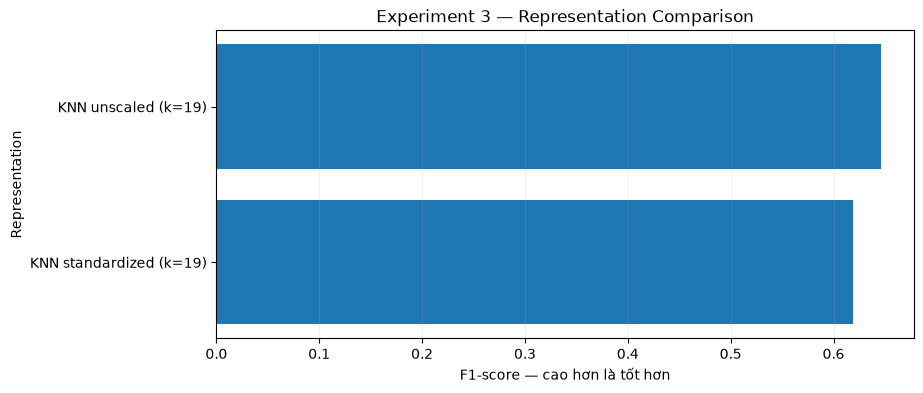

In [16]:
ranking = experiment3_df.sort_values("F1", ascending=True)

plt.figure(figsize=(9, 4))
plt.barh(ranking["Representation"], ranking["F1"])
plt.title("Experiment 3 — Representation Comparison")
plt.xlabel("F1-score — cao hơn là tốt hơn")
plt.ylabel("Representation")
plt.grid(axis="x", alpha=0.2)
plt.show()


# 9. Lựa chọn Final Model

Không lưu model ngay sau Experiment 1.

Ta tạo 3 ứng viên cuối:

1. **Winner của Experiment 1** — model tốt nhất trong 5 model cơ bản.
2. **Tuned Decision Tree** — cấu hình `max_depth` tốt nhất từ Experiment 2.
3. **Best KNN Representation** — representation tốt nhất của KNN `k=19` từ Experiment 3.

Ba ứng viên được so sánh trên **Validation set**.

Sau khi chọn cấu hình cuối cùng:

```text
Final configuration
→ fit lại trên toàn bộ Train + Validation (80%)
→ đánh giá đúng 1 lần trên Final Test (20%)
→ save diabetes.sav
```


In [17]:
# Candidate 1 — Winner của Experiment 1
candidate1 = clone(experiment1_models[experiment1_winner])

# Candidate 2 — Tuned Decision Tree
candidate2 = Pipeline([
    ("preprocess", clone(standard_preprocessor)),
    ("model", DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ))
])

# Candidate 3 — Best KNN representation
if experiment3_winner == "KNN standardized (k=19)":
    best_knn_preprocessor = standard_preprocessor
else:
    best_knn_preprocessor = unscaled_preprocessor

candidate3 = Pipeline([
    ("preprocess", clone(best_knn_preprocessor)),
    ("model", KNeighborsClassifier(
        n_neighbors=19,
        weights="uniform",
        n_jobs=-1
    ))
])

final_candidates = {
    f"Experiment 1 Winner — {experiment1_winner}": candidate1,
    f"Tuned Decision Tree — max_depth={best_depth}": candidate2,
    f"Best KNN Representation — {experiment3_winner}": candidate3,
}

final_candidate_results = []
fitted_final_candidates = {}

for name, pipeline in final_candidates.items():

    pipeline.fit(X_exp_train, y_exp_train)

    y_pred = pipeline.predict(X_val)
    y_score = pipeline.predict_proba(X_val)[:, 1]

    final_candidate_results.append({
        "Candidate": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1": f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_score),
    })

    fitted_final_candidates[name] = pipeline

final_candidate_df = (
    pd.DataFrame(final_candidate_results)
    .sort_values(
        by=["F1", "ROC-AUC", "Recall"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

display(final_candidate_df.round(4))

final_model_name = final_candidate_df.iloc[0]["Candidate"]

print("Final configuration:", final_model_name)


,Candidate,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Decision Tree — max_depth=4,0.7857,0.6981,0.6852,0.6916,0.8538
1,Experiment 1 Winner — Logistic Regression,0.7792,0.7273,0.5926,0.6531,0.8498
2,Best KNN Representation — KNN unscaled (k=19),0.7792,0.7381,0.5741,0.6458,0.8604


Final configuration: Tuned Decision Tree — max_depth=4


# 10. Fit Final Model và đánh giá trên Test Set

Đây mới là bước đánh giá cuối cùng.

Test set **không được dùng để chọn model hoặc tuning hyperparameter** trước bước này.


In [18]:
# Clone cấu hình đã thắng trên validation
final_model = clone(fitted_final_candidates[final_model_name])

# Fit lại trên toàn bộ 80% train + validation
final_model.fit(X_train_full, y_train_full)

# Đánh giá đúng 1 lần trên final test
final_pred = final_model.predict(X_test)
final_prob = final_model.predict_proba(X_test)[:, 1]

final_test_metrics = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, zero_division=0),
    "Recall": recall_score(y_test, final_pred, zero_division=0),
    "F1": f1_score(y_test, final_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_prob),
}

print("FINAL MODEL:", final_model_name)
display(pd.DataFrame([final_test_metrics], index=["Final Test"]).round(4))


FINAL MODEL: Tuned Decision Tree — max_depth=4


,Accuracy,Precision,Recall,F1,ROC-AUC
Final Test,0.7987,0.7091,0.7222,0.7156,0.8248


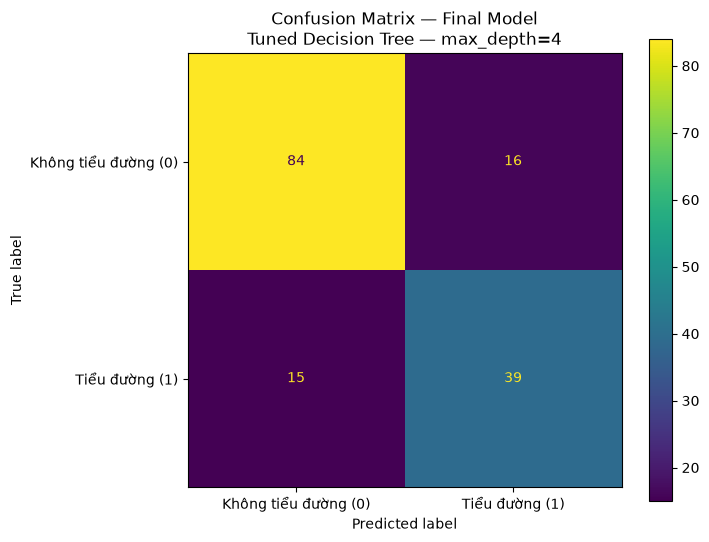

True Negative : 84
False Positive: 16
False Negative: 15
True Positive : 39


In [19]:
cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Không tiểu đường (0)", "Tiểu đường (1)"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix — Final Model\n{final_model_name}")
plt.grid(False)
plt.show()

tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)


# 11. Xuất Final Model

Lưu **toàn bộ Pipeline**, gồm preprocessing + classifier.

Tên file được dùng trực tiếp cho REST API:

```text
diabetes.sav
```


In [20]:
MODEL_PATH = Path("diabetes.sav")

joblib.dump(final_model, MODEL_PATH)

print("Final Model:", final_model_name)
print("Đã lưu:", MODEL_PATH.resolve())

# Kiểm tra load lại
loaded_model_check = joblib.load(MODEL_PATH)

print("\nLoad lại thành công:")
print(loaded_model_check)


Final Model: Tuned Decision Tree — max_depth=4
Đã lưu: C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\diabetes.sav

Load lại thành công:
Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,
                                        random_state=42))])


# 12. Triển khai trên Mobilephone

## Kiến trúc

```text
Mobile App
    |
    | POST /diabetes/v1/predict
    v
REST API
    |
    v
diabetes.sav
    |
    v
Prediction + Confidence
```

## Input linh hoạt

Model được train với **8 feature**, vì vậy DataFrame đưa vào model luôn phải có đủ **8 cột**.

Tuy nhiên ứng dụng có thể cho người dùng nhập **từ 2 trường trở lên**.

Ví dụ client chỉ nhập:

```json
{
  "Glucose": 120,
  "BMI": 28.5
}
```

API phải chuyển thành representation đầy đủ:

```text
Pregnancies                 NaN
Glucose                     120
BloodPressure               NaN
SkinThickness               NaN
Insulin                     NaN
BMI                         28.5
DiabetesPedigreeFunction    NaN
Age                         NaN
```

Sau đó `SimpleImputer(strategy="median")` trong pipeline xử lý các trường còn thiếu.

> Không được xóa hẳn các cột thiếu khỏi DataFrame, vì feature names lúc predict phải giống lúc fit.


# 13. Tổng kết

Notebook đã hoàn thành:

- Diabetes Binary Classification;
- 8 input features;
- xử lý missing value;
- 3 biểu đồ phân phối;
- baseline;
- 5 machine-learning models;
- **KNN cố định `k = 19`**;
- 5 evaluation metrics;
- **Experiment 1 — Model Comparison**;
- **Experiment 2 — Hyperparameter Investigation (`max_depth`)**;
- **Experiment 3 — Representation Investigation (unscaled vs standardized)**;
- Final Model được chọn **sau cả 3 experiments**;
- tuning không dùng final test set;
- Confusion Matrix;
- lưu toàn bộ pipeline thành `diabetes.sav`;
- hỗ trợ REST API cho phép người dùng nhập từ 2 feature trở lên bằng cách để feature thiếu là `NaN`.

Luồng hoàn chỉnh:

```text
Understand
→ Represent
→ Learn
→ Experiment 1
→ Experiment 2
→ Experiment 3
→ Select Final Model
→ Final Test
→ Save
→ Apply
```


In [21]:
# Ma trận đặc trưng X
X = df.drop(columns=["Outcome"]).to_numpy()

# Vector nhãn y
y = df["Outcome"].to_numpy()

print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [22]:
matrix = df.to_numpy()

print(matrix.shape)

(768, 9)
